# Relevance + Stance Classifier

Classify legiscan file (PATH_TO_FILE). It must have columns ["title", "description", "sponsor_parties"], which legiscan files natively have.

In [1]:
!pip install tqdm

In [6]:
from tqdm.auto import tqdm
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

In [7]:
import json, torch
import numpy as np
import pandas as pd
from pathlib import Path
from transformers import AutoTokenizer, BertModel
from sklearn.metrics import accuracy_score, classification_report

In [4]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [5]:
PATH_TO_FILE = '/content/drive/MyDrive/capstone_personal/all_bills_2021_2026.csv'

# Read in all Bills Data
df = pd.read_csv(PATH_TO_FILE, # ../legiscan-joined-all/
                 engine='python',
                 on_bad_lines='skip',)




In [6]:
REL_DIR = Path("/content/drive/MyDrive/capstone_personal/saved_models/lgbtq_relevance_legalbert")
# STANCE_DIR = Path("/content/drive/MyDrive/capstone_personal/saved_models/lgbtq_stance_heuristic")

In [7]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# ---------- Load relevance model ----------
ckpt = torch.load(REL_DIR / "relevance_model.pt", map_location=device)

tokenizer = AutoTokenizer.from_pretrained(REL_DIR)
base_model = BertModel.from_pretrained(ckpt["base_model_name"]).to(device)

class LegalBERTClassifier(torch.nn.Module):
    def __init__(self, bert_model, hidden_size=768, dropout=0.3):
        super().__init__()
        self.bert = bert_model
        self.dropout = torch.nn.Dropout(dropout)
        self.linear = torch.nn.Linear(hidden_size, 1)

    def forward(self, input_ids, attention_mask=None):
        bert_output = self.bert(input_ids=input_ids, attention_mask=attention_mask).last_hidden_state
        cls_output = bert_output[:, 0, :]
        cls_output = self.dropout(cls_output)
        logit = self.linear(cls_output)
        return torch.squeeze(logit)

relevance_model = LegalBERTClassifier(
    base_model,
    hidden_size=ckpt["hidden_size"],
    dropout=ckpt["dropout"]
).to(device)

relevance_model.load_state_dict(ckpt["model_state_dict"])
relevance_model.eval()


config.json: 0.00B [00:00, ?B/s]

pytorch_model.bin:   0%|          | 0.00/440M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

BertModel LOAD REPORT from: nlpaueb/legal-bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.decoder.weight             | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.decoder.bias               | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


LegalBERTClassifier(
  (bert): BertModel(
    (embeddings): BertEmbeddings(
      (word_embeddings): Embedding(30522, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (token_type_embeddings): Embedding(2, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (encoder): BertEncoder(
      (layer): ModuleList(
        (0-11): 12 x BertLayer(
          (attention): BertAttention(
            (self): BertSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): BertSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (LayerNorm): LayerNorm((768,), eps=1e-12, elementwi

In [8]:
from torch.utils.data import DataLoader

@torch.no_grad()
def predict_relevance(texts, batch_size=16, max_length=256, threshold=0.5):
    relevance_model.eval()
    probs = []

    loader = DataLoader(list(texts), batch_size=batch_size, shuffle=False)

    for batch_texts in tqdm(loader, desc="Running LegalBERT relevance inference"):
        enc = tokenizer(
            list(batch_texts),
            padding=True,
            truncation=True,
            max_length=max_length,
            return_tensors="pt"
        ).to(device)

        logits = relevance_model(enc["input_ids"], enc["attention_mask"])
        batch_probs = torch.sigmoid(logits).cpu().numpy()
        probs.append(batch_probs)

    probs = np.concatenate(probs)
    preds = (probs >= threshold).astype(int)

    return probs, preds


Columns needed for classification:
1. For relevance classification, ["title", "description"].

(Accuracy—0.9721083085596237, threshold—0.6, FP rate—around 3.3%.)

2. For stance classification, ['sponsor_parties'] is needed.

(Accuracy—0.9721083085596237)

No information from ACLU or plural is required for this classification. Only Legiscan info + some bill text.


Final accuracy - 0.9721083085596237




In [9]:
df.columns

Index(['state', 'bill_id', 'session_id', 'bill_number', 'status',
       'status_desc', 'status_date', 'title', 'description', 'committee_id',
       'committee', 'last_action_date', 'last_action', 'url', 'state_link',
       'sponsor_names', 'sponsor_parties', 'primary_sponsor', 'sponsor_count',
       'action_count', 'last_history_action', 'document_count',
       'document_types', 'document_urls', 'rollcall_count', 'total_yea',
       'total_nay'],
      dtype='object')

In [10]:
def build_bill_text(df):
    if "description" in df.columns:
        return (df["title"].fillna("") + " " + df["description"].fillna("")).str.strip()
    return df["title"].fillna("")

df["bill_text"] = build_bill_text(df)

In [11]:
df["relevance_prob"], df["relevance_pred"] = predict_relevance(df["bill_text"], threshold=0.6)

Running LegalBERT relevance inference:   0%|          | 0/46652 [00:00<?, ?it/s]

In [12]:
df["relevance_pred"] = [1 if x >= 0.6 else 0 for x in df["relevance_prob"]]

In [13]:
def parse_party_counts(party_str):
    """Parse 'R | D | R | R' into party counts."""
    if pd.isna(party_str):
        return {'R': 0, 'D': 0, 'Other': 0}

    parties = [p.strip() for p in str(party_str).split('|')]
    counts = {
        'R': sum(1 for p in parties if p == 'R'),
        'D': sum(1 for p in parties if p == 'D'),
        'Other': sum(1 for p in parties if p not in ('R', 'D'))
    }
    return counts

# Apply and expand into columns
party_counts = df['sponsor_parties'].apply(parse_party_counts).apply(pd.Series)
df['r_sponsors'] = party_counts['R']
df['d_sponsors'] = party_counts['D']
df['other_sponsors'] = party_counts['Other']


# Derive the dominant party for each bill
def dominant_party(row):
    if row['r_sponsors'] > row['d_sponsors']:
        return 'R'
    elif row['d_sponsors'] > row['r_sponsors']:
        return 'D'
    elif row['r_sponsors'] == 0 and row['d_sponsors'] == 0:
        return 'Other'
    else:
        return 'Bipartisan'


df['dominant_party'] = df.apply(dominant_party, axis=1)

In [14]:
stance_rules = {
    "R": "harmful",
    "D": "supportive",
    "Other": "ambiguous",
    "Bipartisan": "ambiguous"
}

In [15]:
df["pred_stance"] = np.where(
    df["relevance_pred"] == 1,
    df["dominant_party"].map(stance_rules),
    "not applicable"
)

In [16]:
df.to_csv("/content/drive/MyDrive/capstone_personal/bills_classified.csv", index=False)

In [17]:
# df["pred_stance"] = "not_applicable"

# mask = df["relevance_pred"] == 1
# df.loc[mask, "pred_stance"] = df.loc[mask].apply(classify_stance, axis=1)

In [19]:
# y_true = df["applicable"].fillna("Unknown")
# y_pred = df["constructed_dominant_party"].fillna("Unknown")

# party_accuracy = accuracy_score(y_true, y_pred)
# print("Party Accuracy:", party_accuracy)
# print("\nParty Classification Report:\n")
# print(classification_report(y_true, y_pred, zero_division=0))

# Check with LGBTQ key:

In [10]:
# read in data

df = pd.read_csv("/content/drive/MyDrive/capstone_personal/bills_classified.csv")

In [11]:
# Load the unified LGBTQ+ bills dataset (ACLU + Plural merged) of relevant bills
# lgbtq = pd.read_csv('/content/drive/MyDrive/capstone_personal/all_lgbtq_bills_merged.csv')

# no idea what this dataset is
lgbtq = pd.read_csv('/content/drive/MyDrive/capstone_personal/matched_lgbtq_bills.csv')

In [12]:
# Example assumes both have a column called 'bill_id'
# df["is_lgbtq"] = df["bill_id"].isin(lgbtq["bill_id"]).astype(int)

# changed to bill_id AND state

df["is_lgbtq"] = (
    df.merge(
        lgbtq[["bill_id", "state"]].drop_duplicates(),
        on=["bill_id", "state"],
        how="left",
        indicator=True
    )["_merge"]
    .eq("both")
    .astype(int)
)

print("Total bills:", len(df))
print("True LGBTQ bills:", df["is_lgbtq"].sum())

Total bills: 746423
True LGBTQ bills: 2062


In [13]:
lgbtq['true_stance'] = lgbtq['label']


In [14]:
df_check = df.copy().merge(
    lgbtq[["bill_id", "true_stance"]],
    on="bill_id",
    how="left"
)

print("Head:")
print(df_check[["bill_id", "true_stance"]].head())
print("Missing matches:", df_check["true_stance"].isna().sum())


print("\n\nChecking that all true_stance / label NaN values were non-LGBTQ bills...")
test = (df_check.loc[df_check["true_stance"].isna(), "is_lgbtq"] == False).all()
if not test:
      print(df_check.loc[df_check["true_stance"].isna(), "is_lgbtq"] == False)
      raise Exception("Some unexpected true_stance / label NaN values.")
print("...\nAll true_stance / label NaN values were non-LGBTQ bills.")

df_check["true_stance"] = df_check["true_stance"].fillna("not applicable")
print("\nFilled missing matches with \"not applicable\". \nNew Head:")
print(df_check[["bill_id", "true_stance"]].head())



# ["bill_id", "relevance_prob", "relevance_pred", "dominant_party", "pred_stance"]
# ["bill_id", "true_stance"]

Head:
   bill_id true_stance
0  1398079         NaN
1  1398019         NaN
2  1398071         NaN
3  1398080         NaN
4  1398064         NaN
Missing matches: 744361


Checking that all true_stance / label NaN values were non-LGBTQ bills...
...
All true_stance / label NaN values were non-LGBTQ bills.

Filled missing matches with "not applicable". 
New Head:
   bill_id     true_stance
0  1398079  not applicable
1  1398019  not applicable
2  1398071  not applicable
3  1398080  not applicable
4  1398064  not applicable


Now, checking accuracy of each step...

In [15]:
# Checking accuracy of LegalBERT relevance classification

print("Relevance Accuracy:",
      accuracy_score(df_check["is_lgbtq"], df_check["relevance_pred"]))

print("\nRelevance Classification Report:\n")
print(classification_report(df_check["is_lgbtq"], df_check["relevance_pred"]))

Relevance Accuracy: 0.9721083085596237

Relevance Classification Report:

              precision    recall  f1-score   support

           0       1.00      0.97      0.99    744361
           1       0.08      0.81      0.14      2062

    accuracy                           0.97    746423
   macro avg       0.54      0.89      0.56    746423
weighted avg       1.00      0.97      0.98    746423



Stance Accuracy (LGBTQ bills only): 0.7541222114451989

Stance Classification Report:

                precision    recall  f1-score   support

     ambiguous       0.00      0.00      0.00         0
       harmful       0.99      0.77      0.87      1845
not applicable       0.00      0.00      0.00         0
    supportive       0.93      0.65      0.76       217

      accuracy                           0.75      2062
     macro avg       0.48      0.35      0.41      2062
  weighted avg       0.99      0.75      0.85      2062

Number of incorrect rows: 507
Only in TRUE: set()
Only in PRED: {'not applicable', 'ambiguous'}


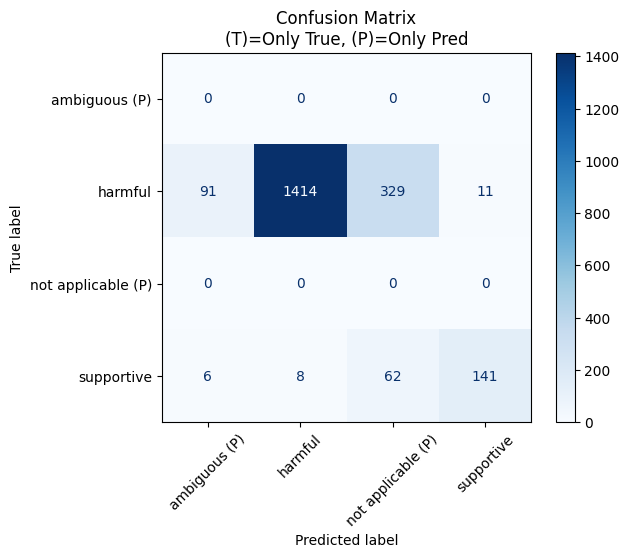

In [17]:
# Checking accuracy of stance classification MINUS "not applicable" (aka non-relevant) results
# aka for only is_lgbtq == True results

# Keep only LGBTQ bills
mask = df_check["is_lgbtq"] == 1

y_true = df_check.loc[mask, "true_stance"]
y_pred = df_check.loc[mask, "pred_stance"]



stance_accuracy = accuracy_score(y_true, y_pred)

print("Stance Accuracy (LGBTQ bills only):", stance_accuracy)

print("\nStance Classification Report:\n")
print(classification_report(y_true, y_pred, zero_division=0))



incorrect = df_check.loc[
    mask &
    df_check["true_stance"].notna() &
    df_check["pred_stance"].notna() &
    (df_check["true_stance"] != df_check["pred_stance"])
]

print("Number of incorrect rows:", len(incorrect))

true_labels = set(y_true)
pred_labels = set(y_pred)

all_labels = sorted(true_labels | pred_labels)

only_true = true_labels - pred_labels
only_pred = pred_labels - true_labels

print("Only in TRUE:", only_true)
print("Only in PRED:", only_pred)


cm = confusion_matrix(y_true, y_pred, labels=all_labels)

cm_df = pd.DataFrame(cm, index=all_labels, columns=all_labels)

def annotate_label(label):
    if label in only_true:
        return f"{label} (T)"
    elif label in only_pred:
        return f"{label} (P)"
    else:
        return label

annotated_labels = [annotate_label(l) for l in all_labels]

cm_df_annotated = pd.DataFrame(
    cm,
    index=annotated_labels,
    columns=annotated_labels
)

cm_df_annotated


disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=annotated_labels
)

disp.plot(cmap="Blues")
plt.xticks(rotation=45)
plt.title("Confusion Matrix\n(T)=Only True, (P)=Only Pred")
plt.show()


# incorrect.head()

In [18]:
# df_check[["relevance_pred", "pred_stance", "is_lgbtq", "true_stance"]][0:100]

In [19]:
# Checking accuracy of stance classification WITH ALL RESULTS
# (includes "not applicable" (aka non-relevant, non-LGBTQ) results
# So: this is equivalent to OVERALL ACCURACY

stance_accuracy = accuracy_score(
    df_check["true_stance"],
    df_check["pred_stance"]
)

print("Stance Accuracy (including ALL bills):", stance_accuracy)

print("\nStance Classification Report:\n")
print(classification_report(
    df_check["true_stance"],
    df_check["pred_stance"],
    zero_division=0
))

Stance Accuracy (including ALL bills): 0.971952900701077

Stance Classification Report:

                precision    recall  f1-score   support

     ambiguous       0.00      0.00      0.00         0
       harmful       0.13      0.77      0.22      1845
not applicable       1.00      0.97      0.99    744361
    supportive       0.01      0.65      0.03       217

      accuracy                           0.97    746423
     macro avg       0.29      0.60      0.31    746423
  weighted avg       1.00      0.97      0.98    746423



In [20]:
# y_true = df["lgbtq_bill_dominant_party"].fillna("Unknown")
# y_pred = df["bill_dominant_party_2"].fillna("Unknown")

# party_accuracy = accuracy_score(y_true, y_pred)
# print("Party Accuracy:", party_accuracy)
# print("\nParty Classification Report:\n")
# print(classification_report(y_true, y_pred, zero_division=0))